# Доповідь 7. Grid Search і Randomized Search: як знайти кращі налаштування моделі
**Тема 4, заняття 5:** практична оцінка точності та налаштування гіперпараметрів моделей машинного навчання · Щербаков Б. В.

**План прикладу:**
1. Задача та модель: Random Forest на даних Titanic (Kaggle), ті самі дані, що в практичній 4.5.
2. Простір гіперпараметрів: 240 комбінацій.
3. `GridSearchCV`: повний перебір усіх 240 комбінацій, кожна перевіряється 5-кратною крос-валідацією.
4. `RandomizedSearchCV`: 30 випадкових комбінацій з того самого простору, теж з 5-кратною крос-валідацією.
5. Порівняння: якість (CV і test), кількість навчань моделі, час.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
%config InlineBackend.figure_formats = ["jpeg"]
plt.rcParams["figure.dpi"] = 80
sns.set_theme(style="whitegrid")
SEED = 42

## 1. Дані та підготовка (як у практичній 4.5)

In [2]:
data = pd.read_csv("../data/titanic.csv")
df = data.copy()
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip().replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
df.loc[~df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df = pd.get_dummies(df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"]),
                    columns=["Sex", "Embarked", "Title"], drop_first=True, dtype=int)
X, y = df.drop(columns="Survived"), df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (712, 13) | test: (179, 13)


## 2. Точка відліку: модель з налаштуваннями за замовчуванням
Гіперпараметри задаються **до** навчання: скільки дерев, наскільки глибоких, скільки об'єктів має бути в листку. Модель сама їх не підбирає.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
default = RandomForestClassifier(random_state=SEED, n_jobs=-1)
default_cv = cross_val_score(default, X_train, y_train, cv=cv).mean()
default_test = accuracy_score(y_test, default.fit(X_train, y_train).predict(X_test))
print(f"За замовчуванням: CV accuracy = {default_cv:.3f}, test accuracy = {default_test:.3f}")

За замовчуванням: CV accuracy = 0.798, test accuracy = 0.804


## 3. Простір пошуку
| Гіперпараметр | Що означає | Значення |
|---|---|---|
| `n_estimators` | кількість дерев | 50, 100, 200, 400 |
| `max_depth` | максимальна глибина дерева | 3, 5, 7, 10, None |
| `min_samples_leaf` | мінімум об'єктів у листку | 1, 2, 4, 8 |
| `max_features` | частка ознак для кожного розбиття | sqrt, 0.5, 1.0 |

**4 × 5 × 4 × 3 = 240 комбінацій.** З 5-кратною крос-валідацією повний перебір означає **1200 навчань моделі**.

In [4]:
param_grid = {
    "n_estimators": [50, 100, 200, 400],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", 0.5, 1.0],
}
n_comb = int(np.prod([len(v) for v in param_grid.values()]))
print("Комбінацій:", n_comb, "| навчань з 5-fold CV:", n_comb * cv.get_n_splits())

Комбінацій: 240 | навчань з 5-fold CV: 1200


## 4. Grid Search: повний перебір
`GridSearchCV` перебирає **всі** комбінації. Кожну оцінює крос-валідацією на train: модель 5 разів навчається на 4/5 даних і перевіряється на 1/5, що залишилась. Середнє з 5 результатів — оцінка комбінації. Test у пошуку не бере участі.

In [5]:
t0 = time.time()
grid = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - t0
print(f"Час: {grid_time:.0f} s")
print("Найкращі параметри:", grid.best_params_)
print(f"Найкраща CV accuracy: {grid.best_score_:.3f}")

Час: 162 s
Найкращі параметри: {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 200}
Найкраща CV accuracy: 0.833


## 5. Randomized Search: випадкова вибірка комбінацій
`RandomizedSearchCV` перевіряє лише **`n_iter` випадкових** комбінацій. Параметри можна задавати не списком, а розподілом (наприклад, будь-яке ціле число дерев від 50 до 400). Беремо 30 комбінацій, тобто 150 навчань замість 1200.

In [6]:
param_dist = {
    "n_estimators": randint(50, 401),
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": randint(1, 9),
    "max_features": ["sqrt", 0.5, 1.0],
}
t0 = time.time()
rand = RandomizedSearchCV(RandomForestClassifier(random_state=SEED), param_dist, n_iter=30, cv=cv,
                          scoring="accuracy", random_state=SEED, n_jobs=-1)
rand.fit(X_train, y_train)
rand_time = time.time() - t0
print(f"Час: {rand_time:.0f} s")
print("Найкращі параметри:", rand.best_params_)
print(f"Найкраща CV accuracy: {rand.best_score_:.3f}")

Час: 26 s
Найкращі параметри: {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 313}
Найкраща CV accuracy: 0.830


## 6. Порівняння

In [7]:
res = pd.DataFrame({
    "Комбінацій перевірено": [1, n_comb, 30],
    "Навчань моделі": [5, n_comb * 5, 30 * 5],
    "CV accuracy": [default_cv, grid.best_score_, rand.best_score_],
    "Test accuracy": [default_test, accuracy_score(y_test, grid.predict(X_test)), accuracy_score(y_test, rand.predict(X_test))],
    "Час, s": [np.nan, grid_time, rand_time],
}, index=["За замовчуванням", "GridSearchCV", "RandomizedSearchCV"])
res.round(3)

,Комбінацій перевірено,Навчань моделі,CV accuracy,Test accuracy,"Час, s"
За замовчуванням,1,5,0.798,0.804,NaN
GridSearchCV,240,1200,0.833,0.827,161.525
RandomizedSearchCV,30,150,0.830,0.821,26.200


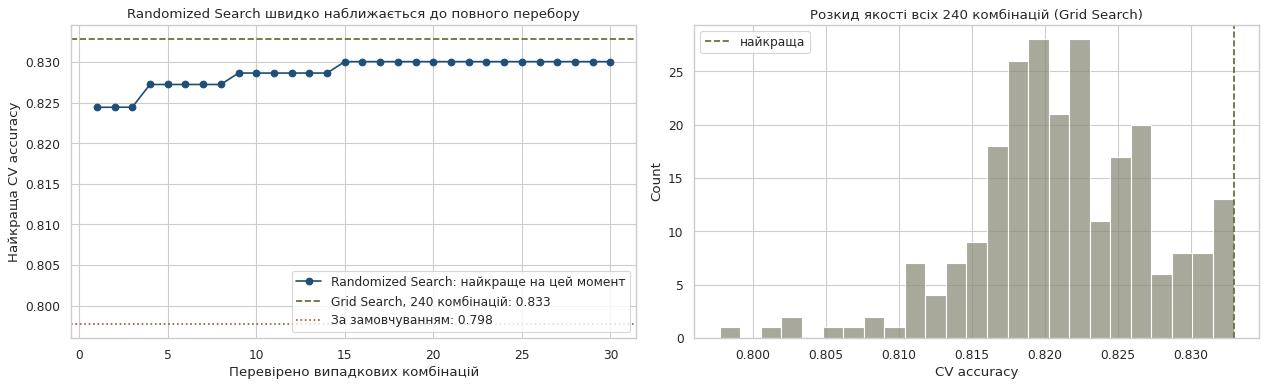

Частка комбінацій у верхніх 10 %: 10%; ймовірність, що 30 випадкових спроб не влучать жодного разу: 0.042


In [8]:
# Наскільки швидко Randomized Search наближається до найкращого результату Grid Search
cvres = pd.DataFrame(rand.cv_results_)
best_so_far = cvres["mean_test_score"].cummax()
gcv = pd.DataFrame(grid.cv_results_)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(range(1, 31), best_so_far, marker="o", color="#1F4E79", label="Randomized Search: найкраще на цей момент")
axes[0].axhline(grid.best_score_, color="#556B2F", ls="--", label=f"Grid Search, 240 комбінацій: {grid.best_score_:.3f}")
axes[0].axhline(default_cv, color="#A0522D", ls=":", label=f"За замовчуванням: {default_cv:.3f}")
axes[0].set_xlabel("Перевірено випадкових комбінацій"); axes[0].set_ylabel("Найкраща CV accuracy")
axes[0].set_title("Randomized Search швидко наближається до повного перебору"); axes[0].legend(loc="lower right")
sns.histplot(gcv["mean_test_score"], bins=25, ax=axes[1], color="#8C8C7A")
axes[1].axvline(grid.best_score_, color="#556B2F", ls="--", label="найкраща")
axes[1].set_title("Розкид якості всіх 240 комбінацій (Grid Search)"); axes[1].set_xlabel("CV accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()
top = (gcv["mean_test_score"] >= gcv["mean_test_score"].quantile(0.9)).mean()
print(f"Частка комбінацій у верхніх 10 %: {top:.0%}; ймовірність, що 30 випадкових спроб не влучать жодного разу: {(1 - 0.10) ** 30:.3f}")

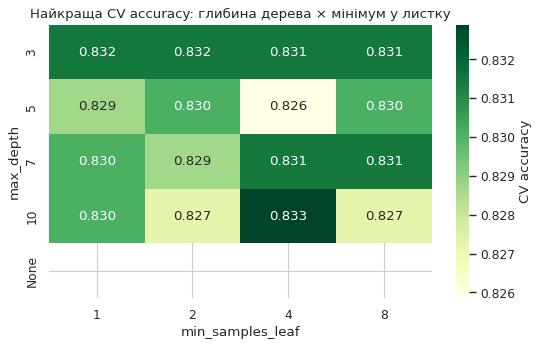

In [9]:
# Вплив двох гіперпараметрів (max_depth × min_samples_leaf), середнє за іншими
piv = gcv.assign(depth=gcv["param_max_depth"].astype(str), leaf=gcv["param_min_samples_leaf"]) \
         .pivot_table(index="depth", columns="leaf", values="mean_test_score", aggfunc="max") \
         .reindex(["3", "5", "7", "10", "None"])
plt.figure(figsize=(7, 4.5))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="YlGn", cbar_kws={"label": "CV accuracy"})
plt.title("Найкраща CV accuracy: глибина дерева × мінімум у листку"); plt.xlabel("min_samples_leaf"); plt.ylabel("max_depth")
plt.tight_layout(); plt.show()

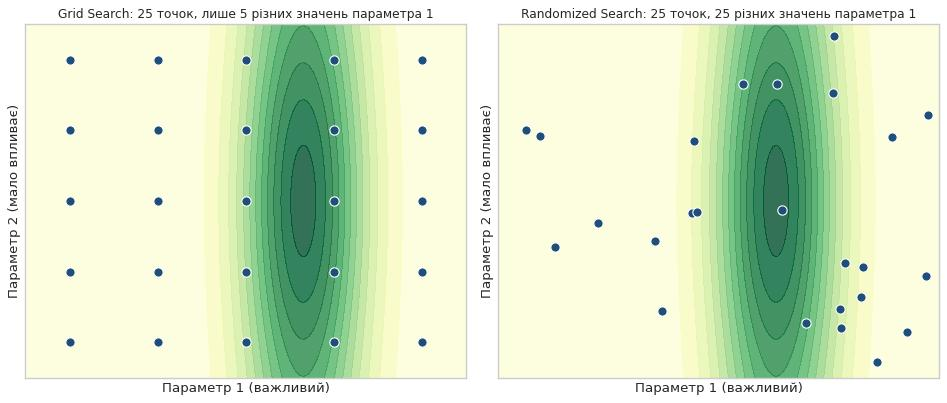

In [10]:
# Схема для слайда: як Grid і Random обирають точки в просторі двох параметрів
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
gx, gy = np.meshgrid(np.linspace(0.1, 0.9, 5), np.linspace(0.1, 0.9, 5))
f = lambda x, yv: np.exp(-((x - 0.63) ** 2) / 0.02) * (0.5 + 0.5 * np.exp(-((yv - 0.5) ** 2) / 0.3))
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
for ax, (px_, py_), t in [(axes[0], (gx.ravel(), gy.ravel()), "Grid Search: 25 точок, лише 5 різних значень параметра 1"),
                          (axes[1], (rng.random(25), rng.random(25)), "Randomized Search: 25 точок, 25 різних значень параметра 1")]:
    ax.contourf(xx, yy, f(xx, yy), levels=12, cmap="YlGn", alpha=0.8)
    ax.scatter(px_, py_, s=70, color="#1F4E79", edgecolor="white", zorder=3)
    ax.set_xlabel("Параметр 1 (важливий)"); ax.set_ylabel("Параметр 2 (мало впливає)"); ax.set_title(t, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig("grid_vs_random_scheme.png", dpi=110); plt.show()

## 7. Висновки

1. **Налаштування гіперпараметрів дає відчутний приріст.** Random Forest з параметрами за замовчуванням має CV accuracy 0.798. Після пошуку маємо 0.833, тобто +3.5 п.п. На незалежному тесті 0.827 проти 0.804.
2. **Grid Search** перевірив усі 240 комбінацій (1200 навчань із 5-fold CV) за 162 s і гарантовано знайшов найкращу комбінацію із заданої сітки: `max_depth=10, max_features=1.0, min_samples_leaf=4, n_estimators=200`.
3. **Randomized Search** перевірив 30 випадкових комбінацій (150 навчань) за 26 s і отримав 0.830, лише на 0.3 п.п. менше. Знайдені параметри практично ті самі. Уже після 15 спроб результат майже дорівнював повному перебору. Причина в тому, що 10 % найкращих комбінацій займають помітну частку простору, і ймовірність не влучити в них за 30 випадкових спроб становить лише ≈ 4 %.
4. **Роль крос-валідації:** кожну комбінацію оцінюємо як середнє з 5 перевірок, тож вибір не залежить від одного випадкового поділу. Тестова вибірка в пошуку не бере участі й використовується один раз, для фінальної оцінки.
5. **Практичне правило:** мало параметрів і швидка модель → Grid Search; великий простір, неперервні параметри чи дорога модель (нейромережі) → Randomized Search. Часто їх поєднують: спершу випадковий пошук знаходить перспективну область, потім невелика сітка навколо неї.